# Analyse prenetworks generated by PyPSA-Earth (sector-coupled)

Notebook to analyse the prenetworkw which are generated during a sector-coupled PyPSA-Earth run 

(Triggered by ```snakemake solve_sector_networks```)

## Import packages

In [16]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import numpy as np
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
from shapely import wkt
import hvplot.pandas

## Path settings

In [18]:
warnings.simplefilter(action='ignore', category=FutureWarning)
# Set your pypsa-earth directory here
PARENT = os.path.realpath("../../pypsa-earth") + "/"
# Set your run name here
run_name = "DZA-48-GADM-sec-netZero-2050"
# Set your sector_name here
sector_name = 'DZA-1'
# Set the name of your network here 
network = 'elec_s_48_ec_lcopt_Co2L-24H_24H_2030_0.071_AB_presec'

In [19]:
# Generate network_subpath
network_subpath = sector_name + "/prenetworks/" + network + ".nc"
# Generate the network path
network_path = PARENT + f"results/{network_subpath}"
# Country shape file
regions_onshore_path = PARENT + f"resources/{run_name}/shapes/country_shapes.geojson"
# Renewable profile file
solar_path = PARENT + f"resources/{run_name}/renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/{run_name}/renewable_profiles/profile_onwind.nc"

## Load the network and shapefile data

In [20]:
# Load the netwwork
n = pypsa.Network(network_path)
# config_path = PARENT + f"/config.yaml"
# config = yaml.safe_load(open(config_path))
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_48_ec_lcopt_Co2L-24H_24H_2030_0.071_AB_presec.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Data import check

Country check

Text(0.5, 1.0, 'DZ')

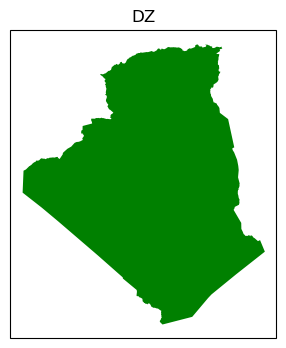

In [21]:
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [22]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 141 entries
Component 'Carrier' has 17 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 96 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 188 entries
Component 'Load' has 47 entries
Component 'Generator' has 127 entries
Component 'StorageUnit' has 1 entries
Component 'Store' has 94 entries


## Plot the network

In [23]:
lines = n.lines
lines["geometry"] = lines["geometry"].apply(wkt.loads)
lines = gpd.GeoDataFrame(lines, crs="epsg:4326")

buses = n.buses
buses["geometry"] = gpd.points_from_xy(buses.lon, buses.lat)
buses = gpd.GeoDataFrame(buses, crs="epsg:4326")

In [24]:
basa_network = buses.hvplot(
    geo=True,
    size=10,  # buses["tag_area"]**(0.5)/10,
    frame_height=750,
    alpha=0.4,
    tiles="CartoLight",
    hover_cols=["bus_id"],
    color="orange",
) * lines.hvplot(geo=True, alpha=0.4, hover_cols=["line_id"]).opts(
    active_tools=["pan", "wheel_zoom"]
)
display(basa_network) # show the plot in the notebook
#hvplot.save(basa_network, "documentation/base_network_buses_lines.html");

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]